In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import numpy as np
import datetime as dt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [49]:
warnings.filterwarnings("ignore")

rentals_df = pd.read_csv('data/rentals.csv')
off_plan_df = pd.read_csv('data/off_plan.csv')
metro_stations_df = pd.read_csv('data/metro_stations.csv')
area_monthly = pd.read_csv('data/area_prices_monthly.csv')

rentals_df.head()

,id,date_listed,community,zone,lat,lon,property_category,property_type,bedrooms,area_sqft,...,parking_spaces,metro_station,metro_line,metro_distance_min,to_burj_khalifa_km,contract_type,n_cheques,annual_rent_usd,rent_per_sqft_usd,rent_per_m2_usd
0,R000001,2024-12-20,Town Square,Nshama,25.02906,55.25610,apartment,1BR,1,748,...,1,Centrepoint,Red,373,18.79,yearly,6,13700,18,196
1,R000002,2021-07-06,Expo City,Dubai South,24.96152,55.15759,apartment,1BR,1,1011,...,2,Expo 2020,Red,7,28.73,yearly,6,12700,12,135
2,R000003,2023-05-10,Palm Jumeirah,Palm Jumeirah,25.10836,55.13304,apartment,1BR,1,825,...,2,Mashreq Bank,Red,44,17.32,yearly,1,59900,72,782
3,R000004,2021-12-30,Deira,Deira,25.28720,55.30205,apartment,1BR,1,755,...,1,Al Jafiliya,Red,62,10.39,yearly,1,9300,12,133
4,R000005,2023-12-08,The Views,The Greens,25.08438,55.18399,apartment,1BR,1,746,...,1,Dubai Internet City,Red,5,15.50,short_term,12,31300,41,451


In [4]:
off_plan_df.head()

,id,date_listed,project_id,project_name,developer,developer_tier,community,zone,lat,lon,...,total_project_units,payment_plan,metro_station,metro_line,metro_distance_min,to_burj_khalifa_km,price_usd,price_per_sqft_usd,price_per_m2_usd,mortgage_rate_at_listing
0,O000001,2025-02-22,OP0015,Hartland Greens,Ellington,tier2,Dubai Production City,IMPZ,25.02540,55.25064,...,1500,10/90_post_handover,Dubai Internet City,Red,136,19.25,196600,293,3149,6.15
1,O000002,2021-03-19,OP0165,Aykon City,Sobha,tier1,The Meadows,Emirates Living,25.04572,55.17040,...,1500,50/50_post_handover,MRT-1,Red,51,19.83,3712600,621,6689,1.90
2,O000003,2021-02-16,OP0091,Beachgate,Nakheel,tier1,Jumeirah Park,Emirates Living,25.04807,55.17198,...,100,70/30,Abu Baker Al Siddique,Red,367,19.53,1521500,597,6424,1.90
3,O000004,2021-11-24,OP0165,Aykon City,Sobha,tier1,The Meadows,Emirates Living,25.04572,55.17040,...,1500,70/30,Al Furjan,Red,37,19.83,2976600,912,9816,1.90
4,O000005,2021-02-04,OP0130,Marina Vista,Dubai Properties,tier1,Liwan,Dubailand,25.06191,55.32871,...,400,60/40,Abu Hail,Red,306,16.01,112200,200,2154,1.90


In [5]:
metro_stations_df.head()

,station_name,line,lat,lon,year_opened,to_burj_khalifa_km
0,UAE Exchange,Red,24.9756,55.0700,2011,32.11
1,Energy,Red,24.9844,55.0866,2011,30.29
2,Ibn Battuta,Red,25.0445,55.1180,2011,23.16
3,Jebel Ali,Red,25.0050,55.1335,2011,25.65
4,Danube,Red,25.0185,55.1230,2011,25.04


In [21]:
def summarize_frame(df):
    summary = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_pct': df.isna().mean()*100,
        'unique': df.nunique(dropna=True),
        })
    return summary.sort_values(['missing_pct', 'unique'], ascending=[False, False])

rentals_df['date_listed'] = pd.to_datetime(rentals_df['date_listed'])
date_min = rentals_df['date_listed'].min().date()
date_max = rentals_df['date_listed'].max().date()

print(f'Date range: {date_min} to {date_max}')
print(f'Rows: {len(rentals_df):,}')
display(summarize_frame(rentals_df))

target_summary = rentals_df['annual_rent_usd'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
display(target_summary.to_frame('annual_rent_usd'))

Date range: 2021-01-01 to 2026-04-29
Rows: 25,000


,dtype,missing,missing_pct,unique
id,object,0,0.0,25000
lat,float64,0,0.0,16339
lon,float64,0,0.0,16190
area_sqft,int64,0,0.0,6010
area_m2,float64,0,0.0,5712
annual_rent_usd,int64,0,0.0,3507
to_burj_khalifa_km,float64,0,0.0,3243
date_listed,datetime64[ns],0,0.0,1945
rent_per_m2_usd,int64,0,0.0,1407
metro_distance_min,int64,0,0.0,502


,annual_rent_usd
count,2.500000e+04
mean,8.368702e+04
std,9.886345e+04
min,2.200000e+03
1%,5.000000e+03
5%,8.000000e+03
50%,4.705000e+04
95%,2.686150e+05
99%,4.583030e+05
max,1.596500e+06


In [23]:
metro_stations_df.nunique()

station_name          55
line                   2
lat                   49
lon                   43
year_opened            4
to_burj_khalifa_km    51
dtype: int64

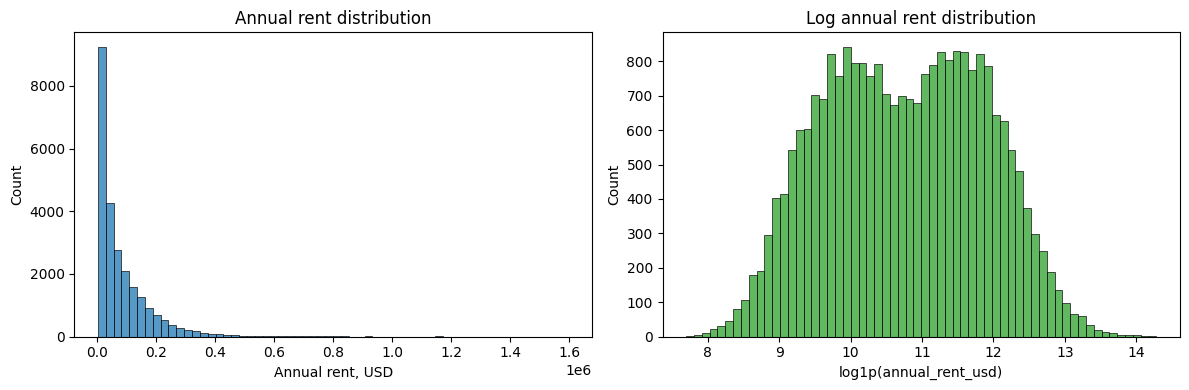

In [28]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(rentals_df['annual_rent_usd'], bins=60, ax=axes[0])
axes[0].set_title('Annual rent distribution')
axes[0].set_xlabel('Annual rent, USD')

sns.histplot(np.log1p(rentals_df['annual_rent_usd']), bins=60, ax=axes[1], color='tab:green')
axes[1].set_title('Log annual rent distribution')
axes[1].set_xlabel('log1p(annual_rent_usd)')

plt.tight_layout()
plt.show()

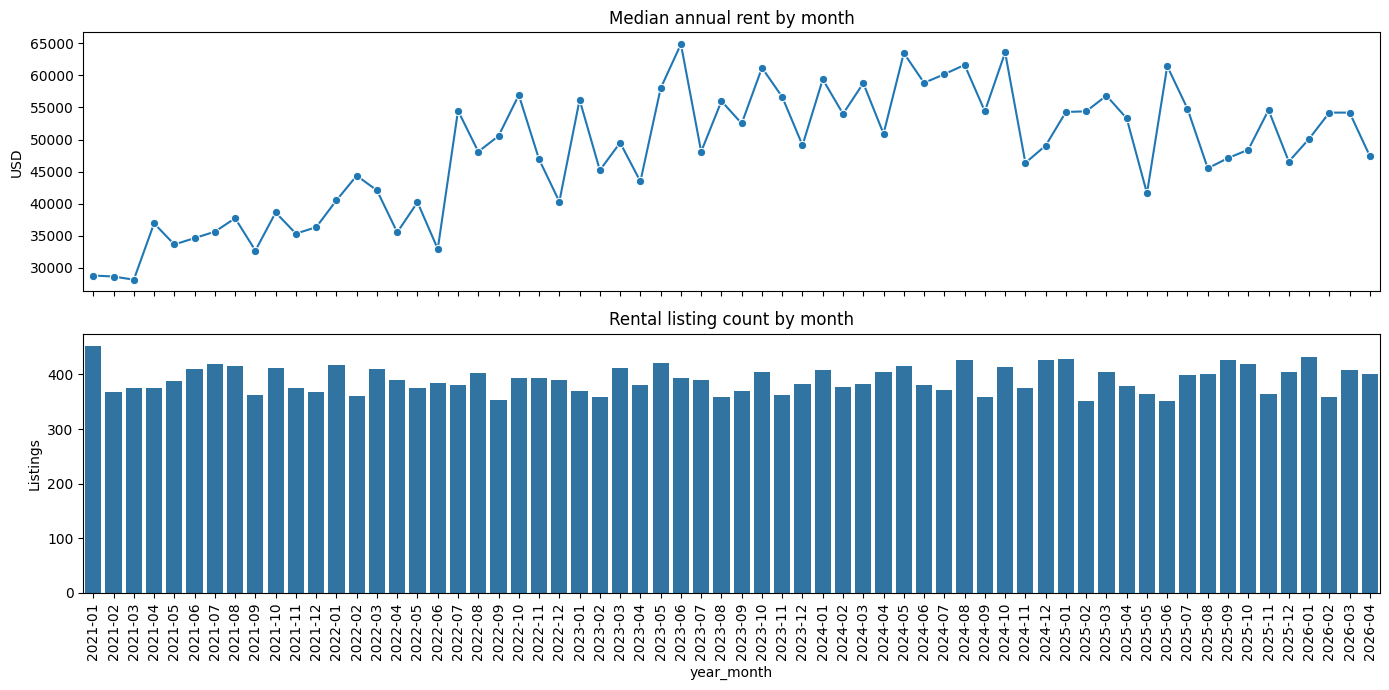

In [36]:
rentals_eda = rentals_df.copy()
rentals_eda['year_month'] = rentals_eda['date_listed'].dt.to_period('M').astype(str)

monthly_rent = (
    rentals_eda.groupby('year_month')
    .agg(
        median_rent=('annual_rent_usd', 'median'),
        median_rent_per_sqft=('rent_per_sqft_usd', 'median'),
        listings=('id', 'count'),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14,7), sharex=True)

sns.lineplot(data=monthly_rent, x='year_month', y='median_rent', marker='o', ax=axes[0])
axes[0].set_title('Median annual rent by month')
axes[0].set_ylabel('USD')

sns.barplot(data=monthly_rent, x='year_month', y='listings', ax=axes[1])
axes[1].set_title('Rental listing count by month')
axes[1].set_ylabel('Listings')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

,,listings,median_rent,median_rent_per_sqft,median_area
community,zone,,,,
Emirates Hills,Emirates Hills,280,312900.0,79.0,3923.0
Bulgari Resort,Jumeirah Bay,301,234600.0,138.0,1589.0
Umm Suqeim,Jumeirah,279,209400.0,51.0,4093.0
Jumeirah Islands,Emirates Living,290,196050.0,51.0,3941.0
The Meadows,Emirates Living,261,181100.0,47.0,3810.0
Jumeirah Park,Emirates Living,278,173450.0,43.0,3926.5
The Lakes,Emirates Living,318,167900.0,43.0,3866.0
Arabian Ranches 2,Arabian Ranches,292,166300.0,43.0,3890.0
Arabian Ranches 3,Arabian Ranches,321,162400.0,44.0,3849.0


,,listings,median_rent,median_rent_per_sqft,median_area
community,zone,,,,
Discovery Gardens,Discovery Gardens,277,14900.0,16.0,949.0
Dubai Studio City,Dubai Studio City,287,14100.0,15.0,828.0
Dubai Sports City,Dubai Sports City,284,13850.0,16.0,829.5
Dubai Investment Park,DIP,309,13800.0,15.0,868.0
Liwan,Dubailand,295,13600.0,16.0,823.0
Al Qusais,Al Qusais,312,13300.0,16.0,834.0
Dubai Production City,IMPZ,291,13200.0,14.0,874.0
Town Square,Nshama,309,12800.0,15.0,840.0
Remraam,Dubailand,311,12700.0,13.0,924.0


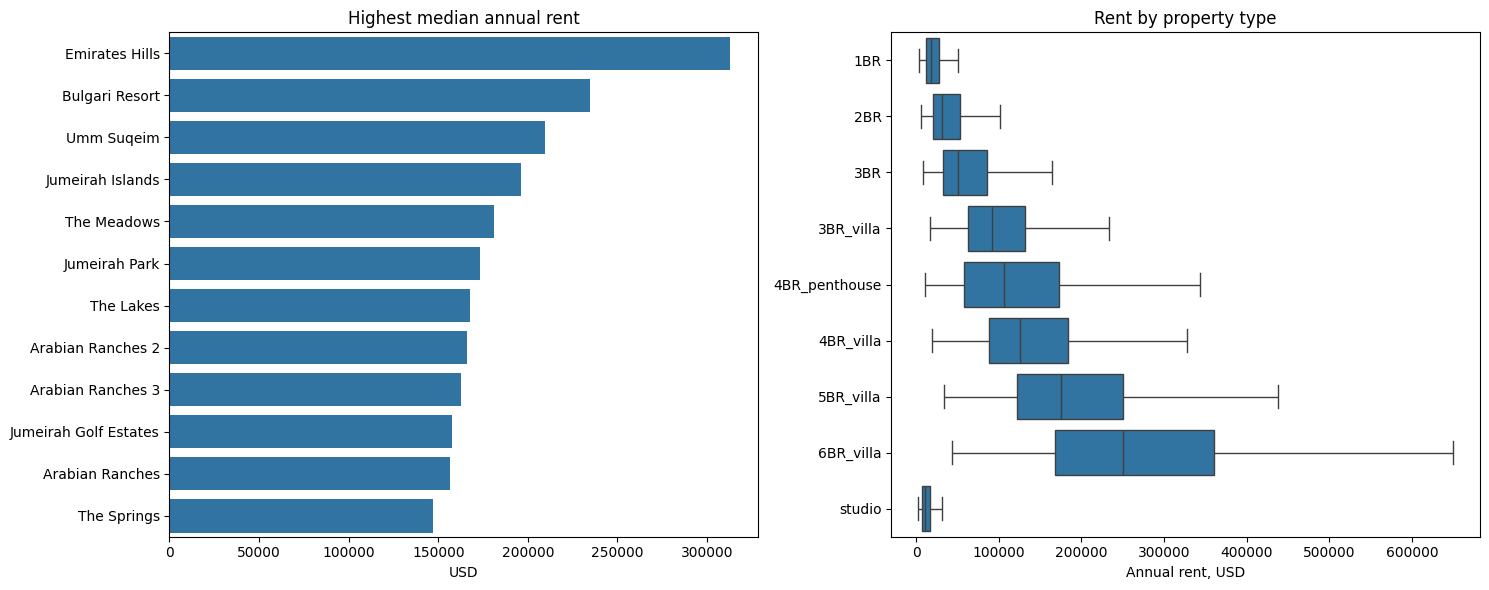

In [39]:
community_stats = (
    rentals_eda.groupby(['community', 'zone'])
    .agg(
        listings=('id', 'count'),
        median_rent=('annual_rent_usd', 'median'),
        median_rent_per_sqft=('rent_per_sqft_usd', 'median'),
        median_area=('area_sqft', 'median'),
    )
    .query('listings >= 80')
    .sort_values('median_rent', ascending=False)
)

display(community_stats.head(11))
display(community_stats.tail(11))

fig, axes = plt.subplots(1, 2, figsize=(15,6))

top_communities = community_stats.head(12).reset_index()
sns.barplot(data=top_communities, y='community', x='median_rent', ax=axes[0])
axes[0].set_title('Highest median annual rent')
axes[0].set_xlabel('USD')
axes[0].set_ylabel('')


property_order = rentals_eda.groupby('property_type')['annual_rent_usd'].median().sort_index().index
sns.boxplot(
    data=rentals_eda,
    y='property_type',
    x='annual_rent_usd',
    order=property_order,
    showfliers=False,
    ax=axes[1],
)

axes[1].set_title('Rent by property type')
axes[1].set_xlabel('Annual rent, USD')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [46]:
rentals_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  25000 non-null  object        
 1   date_listed         25000 non-null  datetime64[ns]
 2   community           25000 non-null  object        
 3   zone                25000 non-null  object        
 4   lat                 25000 non-null  float64       
 5   lon                 25000 non-null  float64       
 6   property_category   25000 non-null  object        
 7   property_type       25000 non-null  object        
 8   bedrooms            25000 non-null  int64         
 9   area_sqft           25000 non-null  int64         
 10  area_m2             25000 non-null  float64       
 11  view                25000 non-null  object        
 12  furnishing          25000 non-null  object        
 13  chiller_included    25000 non-null  bool      

In [82]:
LEAKAGE_COLS = ['annual_rent_usd', 'rent_per_sqft_usd', 'rent_per_m2_usd', 'id', 'area_m2']

rentals_df['date_listed'] = pd.to_datetime(rentals_df['date_listed'])

def add_market_context(df, monthly_df):
    """Add community-month market signals available at listing time."""
    out = df.copy()
    monthly = monthly_df.copy()
    monthly["year_month"] = pd.to_datetime(monthly["year_month"]).dt.to_period("M").astype(str)

    market_cols = [
        "year_month",
        "community",
        "secondary_price_per_sqft_usd",
        "rental_price_per_sqft_annual_usd",
        "n_listings_secondary",
        "n_listings_rental",
        "cbuae_base_rate_pct",
        "avg_mortgage_rate_pct",
    ]
    monthly = monthly[market_cols].rename(columns={
        "secondary_price_per_sqft_usd": "market_secondary_ppsf",
        "rental_price_per_sqft_annual_usd": "market_rent_ppsf",
        "n_listings_secondary": "market_secondary_listings",
        "n_listings_rental": "market_rental_listings",
    })

    out["year_month"] = out["date_listed"].dt.to_period("M").astype(str)
    out = out.merge(monthly, on=["year_month", "community"], how="left")
    return out


def engineer_features(df, monthly_df):
    out = add_market_context(df, monthly_df)

    out["listing_year"] = out["date_listed"].dt.year
    out["listing_month"] = out["date_listed"].dt.month
    out["listing_quarter"] = out["date_listed"].dt.quarter
    out["days_since_start"] = (out["date_listed"] - out["date_listed"].min()).dt.days

    out["log_area_sqft"] = np.log1p(out["area_sqft"])
    out["sqrt_area_sqft"] = np.sqrt(out["area_sqft"])
    out["bedrooms_per_1000_sqft"] = out["bedrooms"] / (out["area_sqft"] / 1000).replace(0, np.nan)
    out["parking_per_bedroom"] = out["parking_spaces"] / out["bedrooms"].replace(0, 1)

    out["is_studio"] = (out["bedrooms"] == 0).astype(int)
    out["is_villa"] = (out["property_category"] == "villa").astype(int)
    out["is_furnished"] = out["furnishing"].isin(["fully_furnished", "semi_furnished"]).astype(int)
    out["is_short_term"] = (out["contract_type"] == "short_term").astype(int)

    out["metro_distance_log1p"] = np.log1p(out["metro_distance_min"])
    out["near_metro_15min"] = (out["metro_distance_min"] <= 15).astype(int)
    out["near_metro_30min"] = (out["metro_distance_min"] <= 30).astype(int)
    out["burj_distance_log1p"] = np.log1p(out["to_burj_khalifa_km"])

    out["lat_round_2"] = out["lat"].round(2).astype(str)
    out["lon_round_2"] = out["lon"].round(2).astype(str)
    out["geo_cell"] = out["lat_round_2"] + "_" + out["lon_round_2"]

    out["property_bedroom_type"] = out["property_category"] + "_" + out["bedrooms"].astype(str)
    out["community_property_type"] = out["community"] + "_" + out["property_type"]

    return out

final_df = engineer_features(rentals_df, area_monthly)
print(final_df.shape)
final_df.head()

(25000, 52)


,id,date_listed,community,zone,lat,lon,property_category,property_type,bedrooms,area_sqft,...,is_short_term,metro_distance_log1p,near_metro_15min,near_metro_30min,burj_distance_log1p,lat_round_2,lon_round_2,geo_cell,property_bedroom_type,community_property_type
0,R000001,2024-12-20,Town Square,Nshama,25.02906,55.25610,apartment,1BR,1,748,...,0,5.924256,0,0,2.985177,25.03,55.26,25.03_55.26,apartment_1,Town Square_1BR
1,R000002,2021-07-06,Expo City,Dubai South,24.96152,55.15759,apartment,1BR,1,1011,...,0,2.079442,1,1,3.392157,24.96,55.16,24.96_55.16,apartment_1,Expo City_1BR
2,R000003,2023-05-10,Palm Jumeirah,Palm Jumeirah,25.10836,55.13304,apartment,1BR,1,825,...,0,3.806662,0,0,2.907993,25.11,55.13,25.11_55.13,apartment_1,Palm Jumeirah_1BR
3,R000004,2021-12-30,Deira,Deira,25.28720,55.30205,apartment,1BR,1,755,...,0,4.143135,0,0,2.432736,25.29,55.3,25.29_55.3,apartment_1,Deira_1BR
4,R000005,2023-12-08,The Views,The Greens,25.08438,55.18399,apartment,1BR,1,746,...,1,1.791759,1,1,2.803360,25.08,55.18,25.08_55.18,apartment_1,The Views_1BR


In [83]:
final_df = final_df.sort_values('date_listed').reset_index(drop=True)

split_idx = int(len(final_df) * 0.8)
train_df = final_df.iloc[:split_idx].copy()
test_df = final_df.iloc[split_idx:].copy()

feature_df = final_df.drop(columns=LEAKAGE_COLS + ["date_listed"], errors="ignore")
feature_columns = feature_df.columns.tolist()

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]
y_train = np.log1p(train_df["annual_rent_usd"])
y_test = np.log1p(test_df["annual_rent_usd"])
y_test_usd = test_df["annual_rent_usd"].values

print("Feature count:", len(feature_columns))

Feature count: 46


In [84]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = X_train.select_dtypes(include="object").columns.tolist()
print("Категориальные колонки:", cat_cols)


encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

X_train_enc[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test_enc[cat_cols] = encoder.transform(X_test[cat_cols])

print(X_train_enc.dtypes.value_counts())

Категориальные колонки: ['community', 'zone', 'property_category', 'property_type', 'view', 'furnishing', 'metro_station', 'metro_line', 'contract_type', 'year_month', 'lat_round_2', 'lon_round_2', 'geo_cell', 'property_bedroom_type', 'community_property_type']
float64    26
int64      16
int32       3
bool        1
Name: count, dtype: int64


In [85]:
try:
    from sklearn.metrics import root_mean_squared_error as _rmse
except Exception:
    def _rmse(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

In [86]:
def regression_metrics(y_true_usd, y_pred_usd):
    y_pred_usd = np.maximum(y_pred_usd, 0)
    rmse = _rmse(y_true_usd, y_pred_usd)
    mae = mean_absolute_error(y_true_usd, y_pred_usd)
    rmsle = _rmse(np.log1p(y_true_usd), np.log1p(y_pred_usd))
    r2 = r2_score(y_true_usd, y_pred_usd)
    mape = np.mean(np.abs((y_true_usd - y_pred_usd) / np.maximum(y_true_usd, 1))) * 100
    return {
        "RMSE_USD": rmse,
        "MAE_USD": mae,
        "RMSLE": rmsle,
        "R2": r2,
        "MAPE_pct": mape,
    }

In [87]:
import xgboost as xgb
import lightgbm as lgb
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [88]:
def xgb_objective(trial):
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 300, 1500),
        "max_depth":          trial.suggest_int("max_depth", 3, 10),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":   trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
    }
    model = xgb.XGBRegressor(**params)
    scores = cross_val_score(
        model, X_train_enc, y_train,
        cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    return scores.mean()

xgb_study = optuna.create_study(direction="maximize")
xgb_study.optimize(xgb_objective, n_trials=35, show_progress_bar=True)

print("XGB best RMSLE (log-scale):", -xgb_study.best_value)
print("XGB best params:", xgb_study.best_params)

xgb_model = xgb.XGBRegressor(**xgb_study.best_params, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_enc, y_train)

xgb_pred_log = xgb_model.predict(X_test_enc)
xgb_pred_usd = np.expm1(xgb_pred_log)
xgb_metrics = regression_metrics(y_test_usd, xgb_pred_usd)
print("XGBoost metrics:", xgb_metrics)

  0%|          | 0/35 [00:00<?, ?it/s]

XGB best RMSLE (log-scale): 0.15525199628130856
XGB best params: {'n_estimators': 999, 'max_depth': 4, 'learning_rate': 0.01575950959253504, 'subsample': 0.512924298927868, 'colsample_bytree': 0.5663387297166182, 'min_child_weight': 9, 'reg_alpha': 0.0012335197791654314, 'reg_lambda': 1.1303034573762831e-07}
XGBoost metrics: {'RMSE_USD': 21183.029296875, 'MAE_USD': 11463.8017578125, 'RMSLE': 0.1539286819179438, 'R2': 0.9577720761299133, 'MAPE_pct': np.float64(12.80545581066486)}


In [89]:
def lgb_objective(trial):
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 300, 1500),
        "max_depth":          trial.suggest_int("max_depth", 3, 10),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":         trial.suggest_int("num_leaves", 20, 300),
        "subsample":          trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples":  trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }
    model = lgb.LGBMRegressor(**params)
    scores = cross_val_score(
        model, X_train_enc, y_train,
        cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
    )
    return scores.mean()


lgb_study = optuna.create_study(direction="maximize")
lgb_study.optimize(lgb_objective, n_trials=35, show_progress_bar=True)

print("LGB best RMSLE (log-scale):", -lgb_study.best_value)
print("LGB best params:", lgb_study.best_params)

lgb_model = lgb.LGBMRegressor(**lgb_study.best_params, random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train_enc, y_train)

lgb_pred_log = lgb_model.predict(X_test_enc)
lgb_pred_usd = np.expm1(lgb_pred_log)
lgb_metrics = regression_metrics(y_test_usd, lgb_pred_usd)
print("LightGBM metrics:", lgb_metrics)

  0%|          | 0/35 [00:00<?, ?it/s]

LGB best RMSLE (log-scale): 0.15651989810279657
LGB best params: {'n_estimators': 1353, 'max_depth': 4, 'learning_rate': 0.01434644246551175, 'num_leaves': 211, 'subsample': 0.6626618265430021, 'colsample_bytree': 0.5930283050181961, 'min_child_samples': 24, 'reg_alpha': 2.615198745776481e-05, 'reg_lambda': 0.3049678543939897}
LightGBM metrics: {'RMSE_USD': 21367.729265530175, 'MAE_USD': 11575.673273625333, 'RMSLE': 0.15569239337671797, 'R2': 0.9570324578795616, 'MAPE_pct': np.float64(12.872768919509396)}


In [90]:
results = pd.DataFrame({
    "XGBoost":  xgb_metrics,
    "LightGBM": lgb_metrics,
}).T

print(results)

              RMSE_USD       MAE_USD     RMSLE        R2   MAPE_pct
XGBoost   21183.029297  11463.801758  0.153929  0.957772  12.805456
LightGBM  21367.729266  11575.673274  0.155692  0.957032  12.872769


XGBoost SHAP


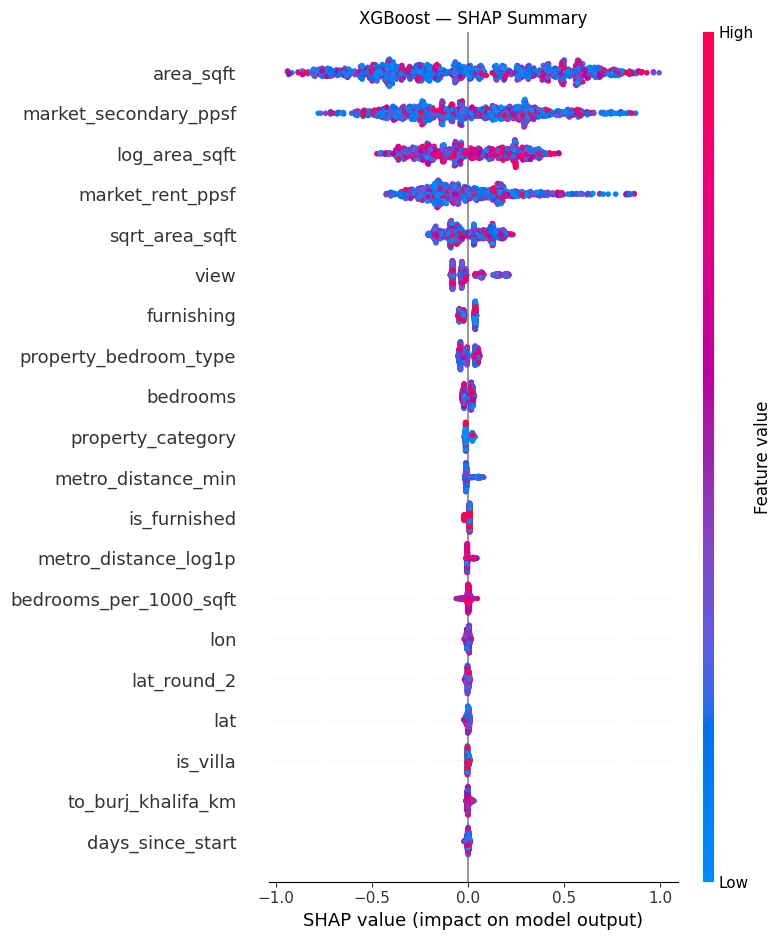

In [107]:
import shap

sample = shap.sample(X_train_enc, 1000, random_state=42)

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(sample)

print("XGBoost SHAP")
plt.figure()
shap.summary_plot(xgb_shap_values, X_train_enc[:1000], max_display=20, show=False)
plt.title("XGBoost — SHAP Summary")
plt.tight_layout()
plt.show()

LightGBM SHAP


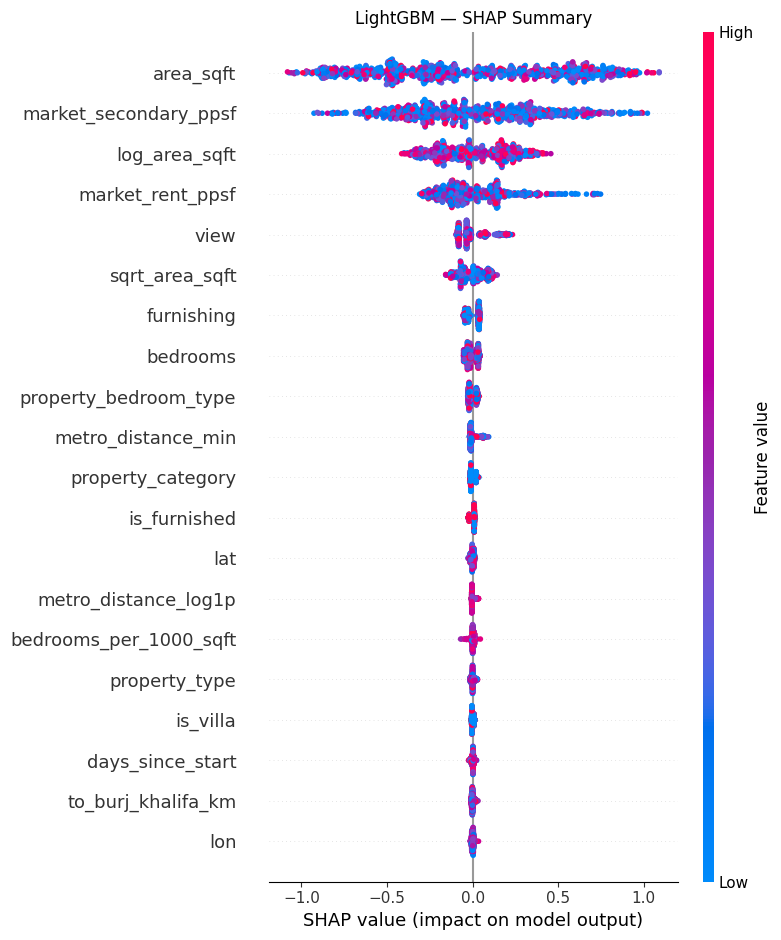

In [93]:
sample = shap.sample(X_train_enc, 1000, random_state=42)

lgb_explainer = shap.TreeExplainer(lgb_model)
lgb_shap_values = lgb_explainer.shap_values(sample)

print("LightGBM SHAP")
plt.figure()
shap.summary_plot(lgb_shap_values, X_train_enc[:1000], max_display=20, show=False)
plt.title("LightGBM — SHAP Summary")
plt.tight_layout()
plt.show()

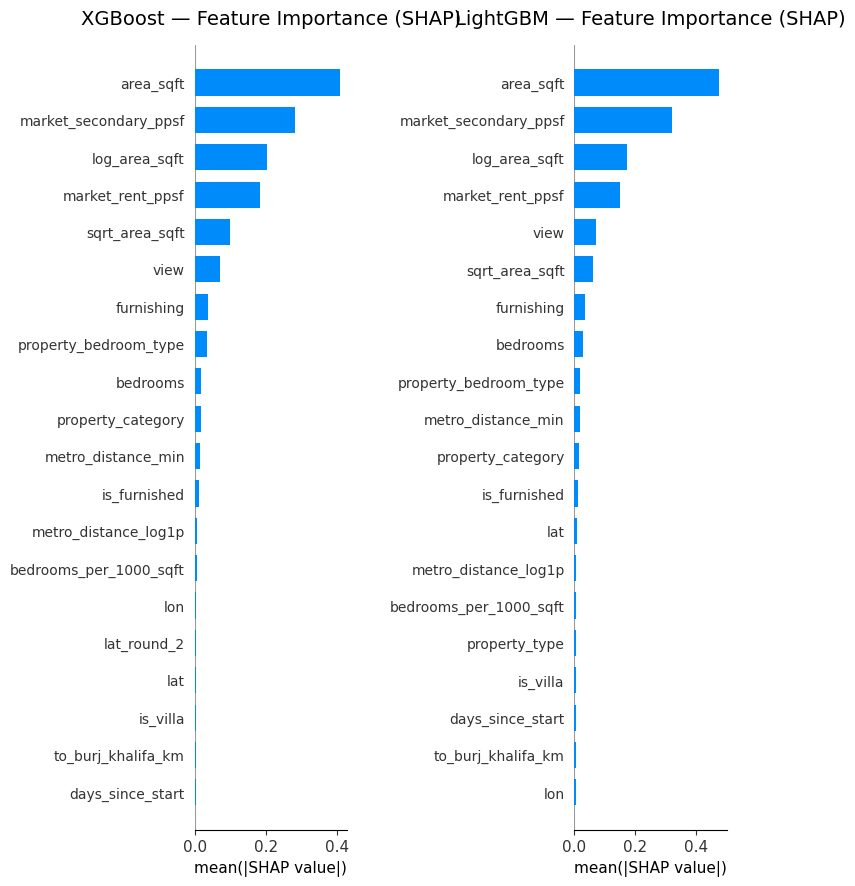

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

plt.sca(axes[0])
shap.summary_plot(
    xgb_shap_values, X_train_enc,
    plot_type="bar",
    max_display=20,
    show=False
)
axes[0].set_title("XGBoost — Feature Importance (SHAP)", fontsize=14, pad=15)
axes[0].set_xlabel("mean(|SHAP value|)", fontsize=11)
axes[0].tick_params(axis='y', labelsize=10)

plt.sca(axes[1])
shap.summary_plot(
    lgb_shap_values, X_train_enc,
    plot_type="bar",
    max_display=20,
    show=False
)
axes[1].set_title("LightGBM — Feature Importance (SHAP)", fontsize=14, pad=15)
axes[1].set_xlabel("mean(|SHAP value|)", fontsize=11)
axes[1].tick_params(axis='y', labelsize=10)

plt.tight_layout(pad=3.0)
plt.show()

In [105]:
xgb_importance = pd.DataFrame({
    "feature": X_train_enc.columns,
    "shap_importance_xgb": np.abs(xgb_shap_values).mean(axis=0)
})

lgb_importance = pd.DataFrame({
    "feature": X_train_enc.columns,
    "shap_importance_lgb": np.abs(lgb_shap_values).mean(axis=0)
})

importance_df = (
    xgb_importance
    .merge(lgb_importance, on="feature")
    .assign(mean_importance=lambda x: (x["shap_importance_xgb"] + x["shap_importance_lgb"]) / 2)
    .sort_values("mean_importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(10))

,feature,shap_importance_xgb,shap_importance_lgb,mean_importance
0,area_sqft,0.407309,0.475463,0.441386
1,market_secondary_ppsf,0.281276,0.318455,0.299865
2,log_area_sqft,0.203261,0.171666,0.187463
3,market_rent_ppsf,0.184395,0.150524,0.167459
4,sqrt_area_sqft,0.098847,0.062142,0.080495
5,view,0.070171,0.071813,0.070992
6,furnishing,0.036725,0.035973,0.036349
7,property_bedroom_type,0.035592,0.019320,0.027456
8,bedrooms,0.016611,0.028632,0.022622
9,metro_distance_min,0.015210,0.016820,0.016015
